# QDIST v4.1 — criterion-referenced computational verification

This notebook replaces the unavailable manual-review gate without manufacturing reviewer labels. It consumes the completed cohort run, verifies its hashes, audits all known-truth and signal-evidence records, assigns final feature-level decisions, and produces corrected Panels G, I, and J plus a self-contained A–J figure suite.

**Scientific boundary:** real-cohort positives remain operational detector outputs. They are not called human-confirmed clipping and are not attributed to a particular microphone, codec, or analog stage. This notebook does not change detector thresholds or feature values and cannot publish or freeze QDIST.

In [1]:
from pathlib import Path
import json
import sys

import pandas as pd
from IPython.display import Image, Markdown, display

def find_project_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / 'config' / 'project.yaml').exists():
            return candidate
    raise FileNotFoundError('Could not find config/project.yaml above the current directory.')

ROOT = find_project_root(Path.cwd())
for folder in (ROOT / 'src', ROOT / 'src'):
    if str(folder) not in sys.path:
        sys.path.insert(0, str(folder))

from paper1_qc_reviewed.qdist_v410_computational_verification import (
    OUTPUT_DIRECTORY,
    run_computational_verification,
)

COHORT_ROOT = (
    ROOT / 'MAIN outputs/02_FEATURE_REVIEWED/00_working_candidates' / 'nonlinear_distortion'
    / 'qdist_v410_candidate_cohort'
)
OVERWRITE_VERIFICATION = False

print('Project:', ROOT)
print('Completed cohort run:', COHORT_ROOT)
print('Verification output:', COHORT_ROOT / OUTPUT_DIRECTORY)

Project: C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1
Completed cohort run: C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1\MAIN outputs/02_FEATURE_REVIEWED/00_working_candidates\nonlinear_distortion\qdist_v410_candidate_cohort
Verification output: C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1\MAIN outputs/02_FEATURE_REVIEWED/00_working_candidates\nonlinear_distortion\qdist_v410_candidate_cohort\computational_verification_v1


## Run the non-destructive verification revision

This is a post-processing run. It does not decode audio or recompute the 519-recording feature table. A pre-existing verification directory is not overwritten unless `OVERWRITE_VERIFICATION=True` is set deliberately.

In [2]:
result = run_computational_verification(
    COHORT_ROOT,
    overwrite=OVERWRITE_VERIFICATION,
)

display(result['checks'])
assert not result['checks']['status'].eq('FAIL').any(), (
    'A verification check failed. Inspect the displayed table before continuing.'
)
assert result['manifest']['human_review_performed'] is False
assert result['manifest']['human_review_required'] is False
assert result['manifest']['feature_values_changed'] is False
assert result['manifest']['freeze_allowed'] is False
print('Verification checks contain no failures.')

,gate,check,status,observed,required
0,G0,completed source run matches its artifact mani...,PASS,matched=923/923; permitted review-archive excl...,all listed source artifacts present with exact...
1,G9,exact-mask cohort-speech reference grid is com...,PASS,cells=12; rows=144,3 geometries x 4 doses x 12 label-blind carriers
2,G9,prespecified moderate-dose occurrence sensitivity,PASS,minimum=1.000000,>=0.90 in every geometry-dose cell at target >...
3,G9,prespecified exact-mask sample precision,PASS,minimum cell median=0.999170; global micro=0.9...,median >=0.90 in every geometry-dose cell at t...
4,G9,conservative recovery and failure modes are qu...,PASS,global micro recall=0.936229; worst carrier-ro...,recall reported without forcing unity; low-bur...
5,G9,exhaustive real-cohort signal-evidence traceab...,PASS,"[{'review_stratum': 'accepted_plateau', 'item_...","all accepted, boundary-rejected, and valid-zer..."
6,G9,manual morphology review,N/A,not performed; no reviewers available; no huma...,not used as criterion reference for this sampl...
7,G10,feature-level retain/conditional/status decisi...,PASS,[{'feature': 'qdist_hard_clipped_sample_fracti...,"explicit decision, role, rationale, unit, and ..."
8,G10,"cross-family arbitration, manuscript wording, ...",PENDING,no longer dependent on human review; requires ...,complete during cross-family integration befor...
9,G10,complete A-J verification figure suite,PASS,A|B|C|D1|D2|D3|E1|E2|E3|F|H1|H2|H3|I|J,A|B|C|D1|D2|D3|E1|E2|E3|F|H1|H2|H3|I|J


Verification checks contain no failures.


## Inspect exact-mask performance and traceability

Occurrence sensitivity and sample precision use the previously declared gates. Recall remains descriptive and deliberately exposes conservative under-recovery, especially at the lowest burdens. The signal-evidence audit verifies ledger linkage; it is not a substitute human label.

In [3]:
display(result['challenge_summary'])
display(result['challenge_audit'])
display(result['morphology_summary'])
display(
    result['morphology_audit'].loc[
        ~result['morphology_audit']['audit_pass']
    ]
)
assert result['morphology_audit']['audit_pass'].all()

,challenge_rows,carrier_count,geometry_count,dose_count,occurrence_detected_n,occurrence_sensitivity,sample_precision_min,sample_precision_median,sample_recall_min,sample_recall_median,micro_precision,micro_recall,true_positive_samples,false_positive_samples,false_negative_samples
0,144,12,3,4,144,1.0,0.994048,0.999378,0.681013,0.939162,0.999073,0.936229,985302,914,67114


,geometry,target_fraction,carrier_count,occurrence_detected_n,occurrence_sensitivity,occurrence_wilson95_low,occurrence_wilson95_high,sample_precision_min,sample_precision_q25,sample_precision_median,sample_recall_min,sample_recall_q25,sample_recall_median,sample_f1_median,micro_precision,micro_recall,true_positive_samples,false_positive_samples,false_negative_samples
0,negative_only,0.0003,12,12,1.0,0.757506,1.0,0.995885,0.997530,0.997907,0.725714,0.848434,0.881672,0.936172,0.998115,0.864744,6355,12,994
1,negative_only,0.0010,12,12,1.0,0.757506,1.0,0.995751,0.998817,0.999170,0.786724,0.901553,0.937863,0.966706,0.998625,0.917693,22511,31,2019
2,negative_only,0.0030,12,12,1.0,0.757506,1.0,0.996189,0.998939,0.999415,0.890792,0.904170,0.945625,0.971776,0.999037,0.930426,68484,66,5121
3,negative_only,0.0100,12,12,1.0,0.757506,1.0,0.995309,0.999339,0.999598,0.894442,0.928322,0.960785,0.979779,0.998992,0.945408,231988,234,13396
4,positive_only,0.0003,12,12,1.0,0.757506,1.0,0.994048,0.997719,0.998168,0.681013,0.837731,0.893624,0.943321,0.998295,0.876582,6442,11,907
5,positive_only,0.0010,12,12,1.0,0.757506,1.0,0.996749,0.999017,0.999358,0.803342,0.876529,0.943548,0.970209,0.999060,0.909769,22313,21,2213
6,positive_only,0.0030,12,12,1.0,0.757506,1.0,0.997297,0.999214,0.999440,0.849861,0.893492,0.952500,0.975297,0.999165,0.926346,68180,57,5421
7,positive_only,0.0100,12,12,1.0,0.757506,1.0,0.995870,0.999330,0.999491,0.905969,0.936744,0.961300,0.980104,0.999043,0.948681,232701,223,12588
8,symmetric,0.0003,12,12,1.0,0.757506,1.0,0.994907,0.997506,0.999071,0.732857,0.830989,0.856926,0.922490,0.998576,0.858737,6310,9,1038
9,symmetric,0.0010,12,12,1.0,0.757506,1.0,0.995907,0.998877,0.999196,0.784604,0.873792,0.910642,0.952880,0.998907,0.894610,21943,24,2585


,review_stratum,item_count,passed_count,failed_count,pass_fraction
0,accepted_plateau,30,30,0,1.0
1,near_threshold_rejection,30,30,0,1.0
2,valid_zero_window,20,20,0,1.0


,blind_id,review_stratum,logical_recording_id,candidate_id,public_index_link,source_recording_link,candidate_ledger_link,accepted_ledger_link,episode_ledger_link,all_accepted_predicates_pass,ledger_decision_matches_stratum,rejection_reason_matches,recording_state_matches_stratum,observed_rejection_reason,audit_pass


## Final feature-level decisions

These decisions complete the family-level scientific registry. Cross-family arbitration, manuscript wording, and immutable freeze remain later integration tasks; none depends on obtaining manual reviewers.

In [4]:
display(result['decisions'])
display(
    result['checklist'].groupby('status', dropna=False)
    .size().rename('item_count').reset_index().sort_values('status')
)
display(
    result['checklist'].loc[
        result['checklist']['status'].isin(['FAIL', 'PENDING', 'CONDITIONAL']),
        ['gate', 'item_id', 'status', 'requirement', 'evidence_path_notes'],
    ]
)

,feature,final_role,decision,analysis_use,unit,rationale,permitted_interpretation,prohibited_interpretation
0,qdist_hard_clipped_sample_fraction,PRIMARY,RETAIN,main QDIST burden view,fraction of finite channel samples,Exact sample-mask reference; micro precision a...,conservative accepted hard-plateau support in ...,unbiased fraction of all physically clipped sa...
1,qdist_hard_clip_event_rate_per_min,SECONDARY,RETAIN,secondary temporal-occurrence view,merged accepted episodes per finite exposure m...,Adds temporal distinctness; occurrence is stab...,episode rate conditional on the governed detec...,physical clipping-event count independent of d...
2,qdist_hard_clipped_frame_fraction,CONDITIONAL_AUDIT,RETAIN_CONDITIONALLY,audit/legacy compatibility only; exclude from ...,fraction of complete 30-ms frames intersecting...,Redundant with the other views and measurably ...,30-ms frame-grid occupancy audit view,"primary burden measure, frame-origin invariant..."
3,qdist_occurrence,COMPANION_STATUS,RETAIN_AS_STATUS,zero-inflation/status summaries; not counted a...,binary observed occurrence when QDIST is avail...,Makes sparse structural zeros explicit without...,at least one operationally accepted QDIST epis...,"recording acceptability gate, diagnosis, or pr..."


,status,item_count
0,CONDITIONAL,5
1,N/A,2
2,PASS,48
3,PENDING,5


,gate,item_id,status,requirement,evidence_path_notes
3,G5,C4,PENDING,Cross-family arbitration rules are defined for...,work/qdist_deep_audit/QDIST_Scientific_Audit_a...
4,G5/G10,C5,PENDING,Residual physiology/phenotype confounding is e...,work/qdist_deep_audit/QDIST_Scientific_Audit_a...
5,G10,C6,CONDITIONAL,Family label matches what is actually measured.,C:\Users\musikicn\Desktop\Nevena_project\Paper...
21,G3,T3,CONDITIONAL,Resampling sensitivity is quantified at realis...,src/paper1_qc/qdist.py; src/paper1_qc...
22,G3,T4,CONDITIONAL,Codec/re-encoding sensitivity is quantified wh...,src/paper1_qc/qdist.py; src/paper1_qc...
28,G5,X1,CONDITIONAL,Matched competing mechanisms are tested at com...,C:\Users\musikicn\Desktop\Nevena_project\Paper...
29,G5,X2,PENDING,Neighboring-family triggers are tested and arb...,work/qdist_deep_audit/QDIST_Scientific_Audit_a...
30,G5,X3,CONDITIONAL,Disease-phenotype or speech-content controls a...,C:\Users\musikicn\Desktop\Nevena_project\Paper...
58,G10,G11,PENDING,"Executed notebook, tests, registry, figures, t...",C:\Users\musikicn\Desktop\Nevena_project\Paper...
59,G10,G12,PENDING,Manuscript wording and feature census match th...,C:\Users\musikicn\Desktop\Nevena_project\Paper...


## Corrected verification and decision panels

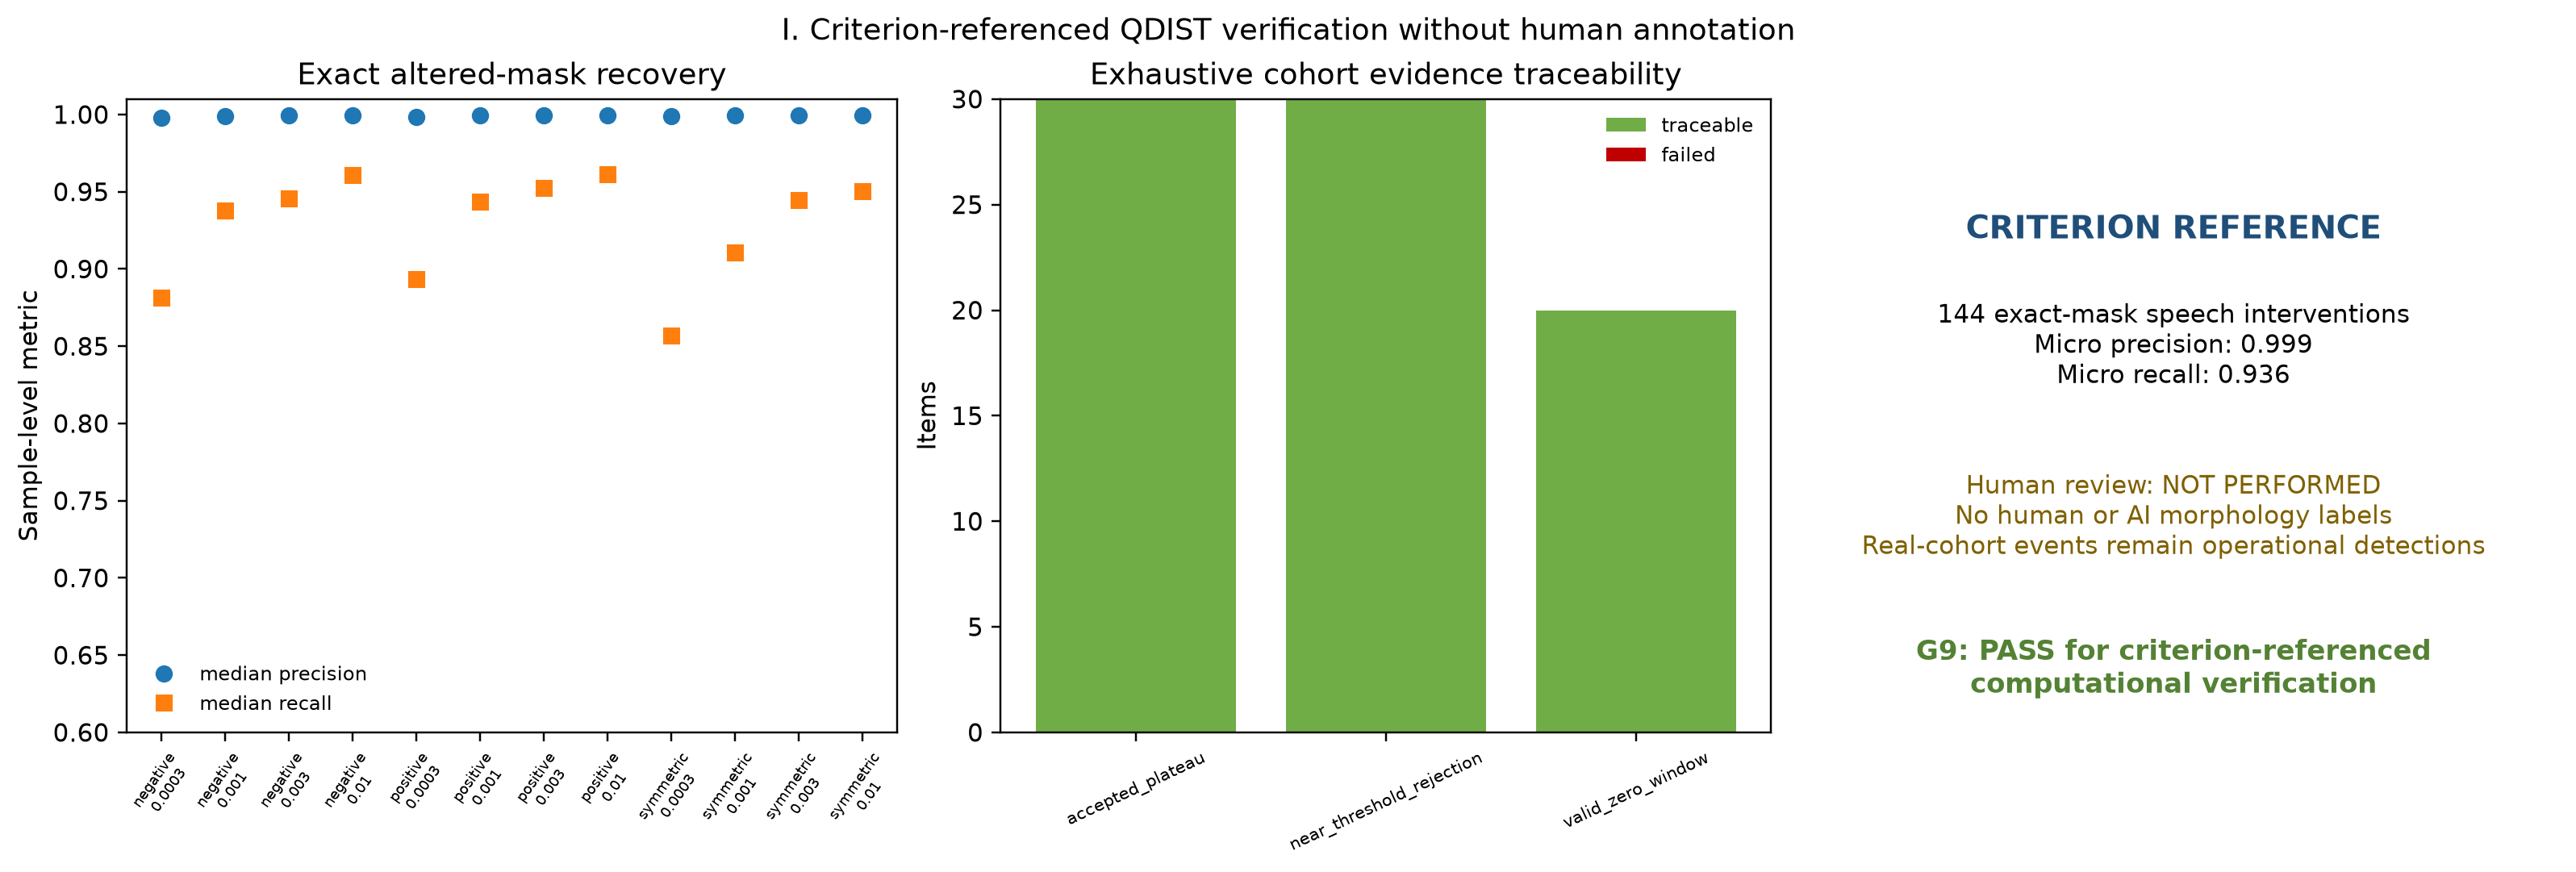

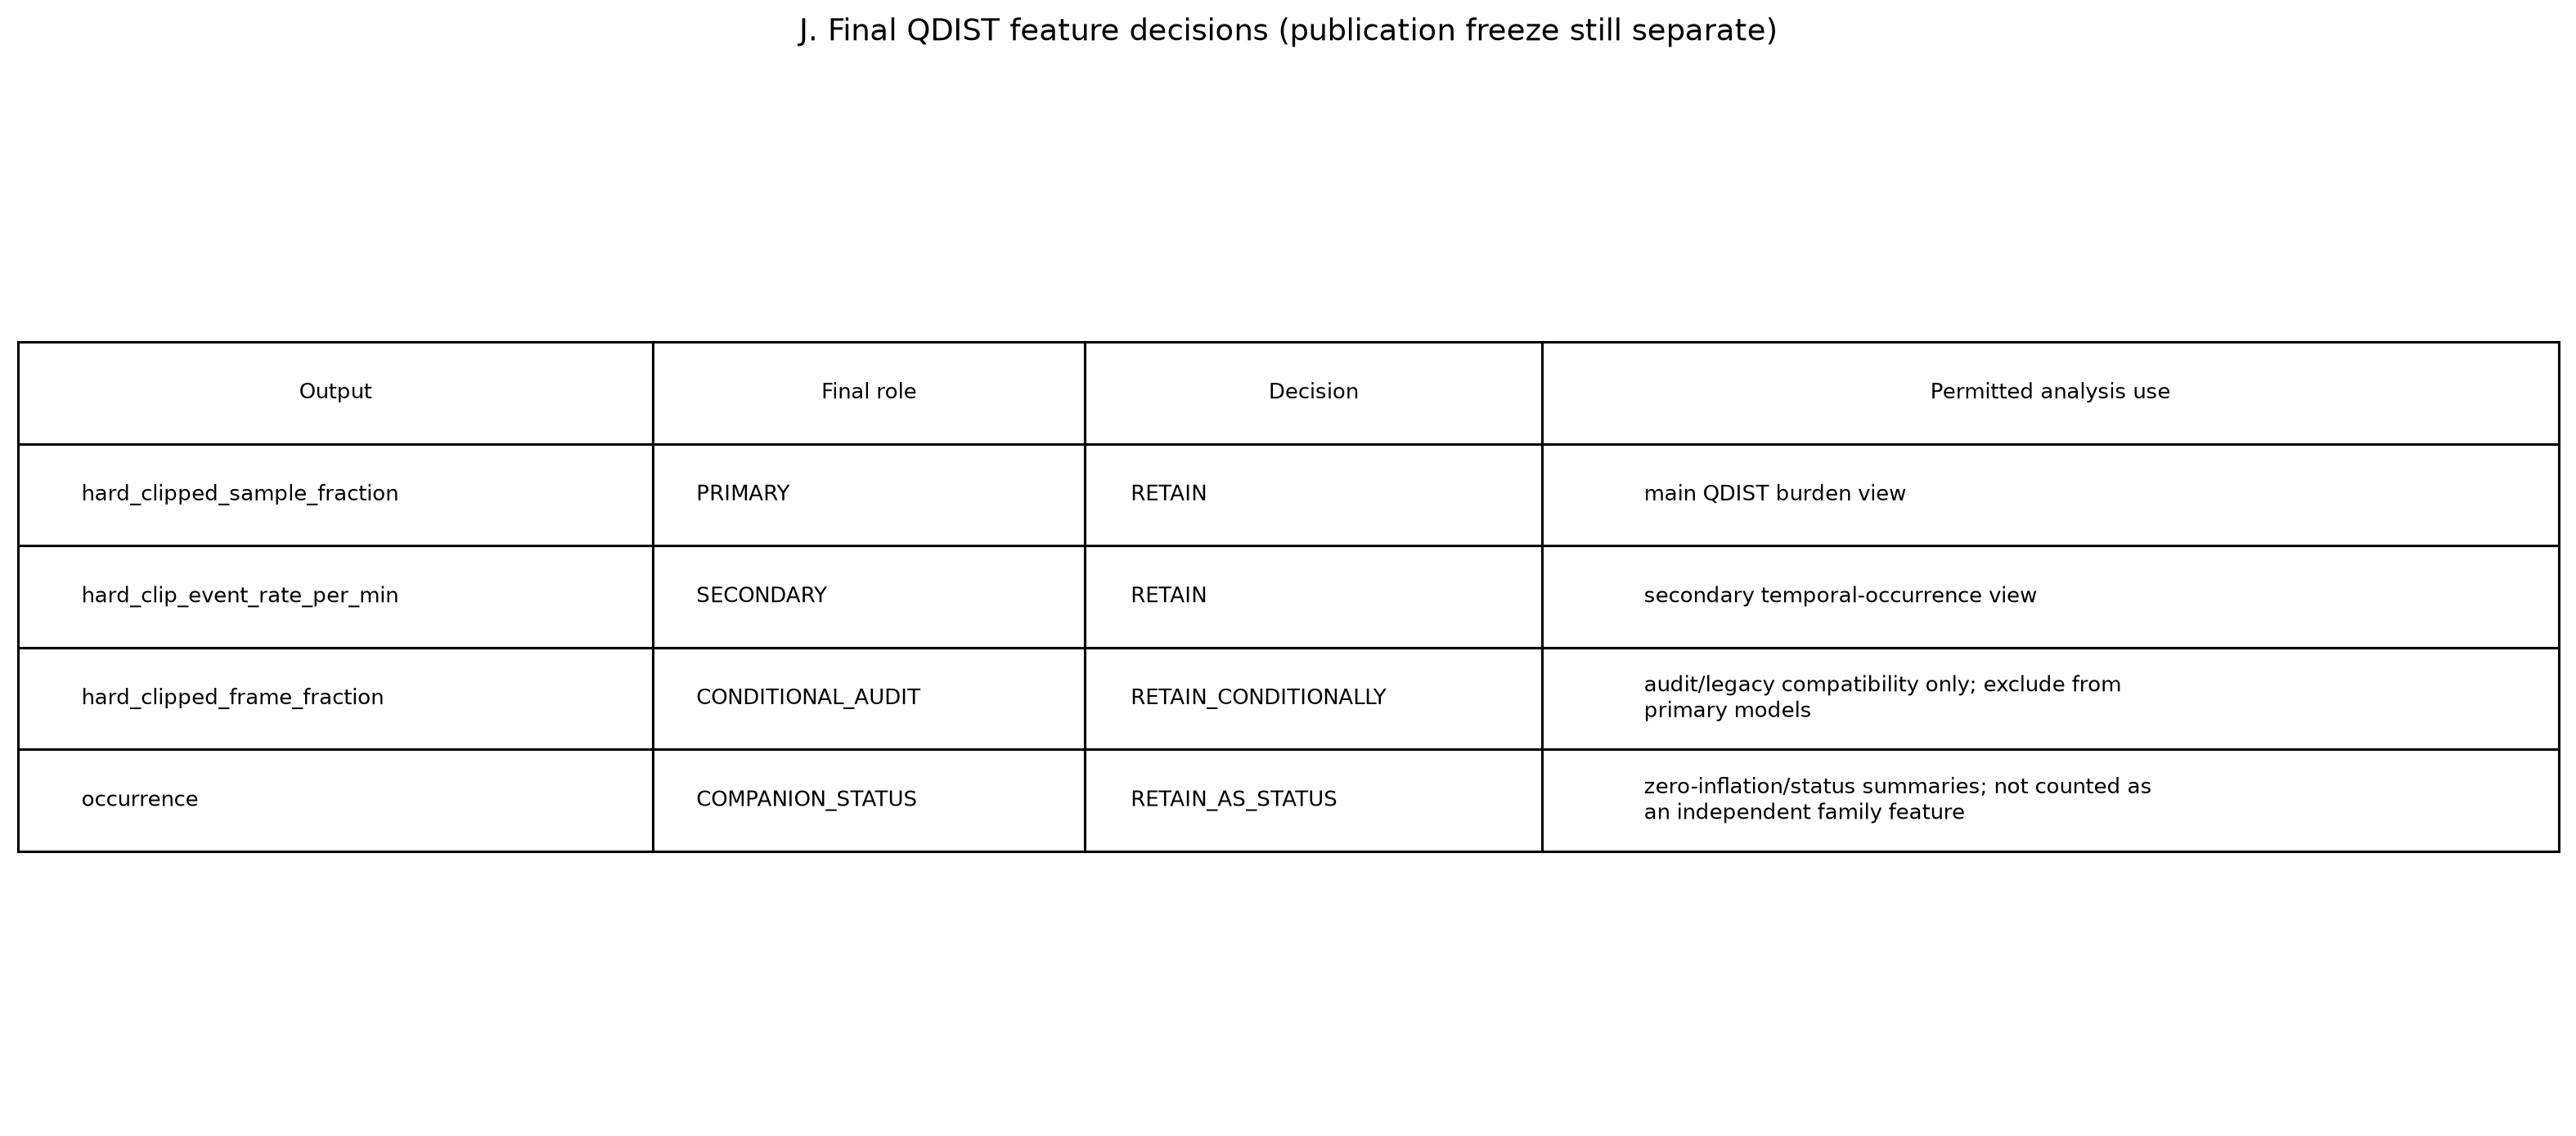

In [5]:
verification_root = result['output_root']
panel_i = verification_root / 'figures' / 'qdist_v410_panel-I_computational-verification.png'
panel_j = verification_root / 'figures' / 'qdist_v410_panel-J_final-feature-decisions.png'
display(Image(filename=str(panel_i)))
display(Image(filename=str(panel_j)))

## Handoff

Upload the completed `computational_verification_v1` directory (or a ZIP of it) for the final cross-check. The generated report states exactly what is validated, what is not validated, and the remaining non-reviewer tasks before freeze.

In [6]:
print('Completed verification output:', result['output_root'])
print('Scientific report:', result['report_path'])
print('Manifest:', result['manifest_path'])
print('Next: upload computational_verification_v1 for final inspection.')

Completed verification output: C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1\MAIN outputs/02_FEATURE_REVIEWED/00_working_candidates\nonlinear_distortion\qdist_v410_candidate_cohort\computational_verification_v1
Scientific report: C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1\MAIN outputs/02_FEATURE_REVIEWED/00_working_candidates\nonlinear_distortion\qdist_v410_candidate_cohort\computational_verification_v1\reports\QDIST_v410_Computational_Verification_and_Decision_Report.md
Manifest: C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1\MAIN outputs/02_FEATURE_REVIEWED/00_working_candidates\nonlinear_distortion\qdist_v410_candidate_cohort\computational_verification_v1\manifests\qdist_v410_computational_verification_manifest.json
Next: upload computational_verification_v1 for final inspection.
